# Life Expectancy Regression Analysis - Machine Learning HW2

Davide De Blasio - 2082600

December 2025



This project performs comprehensive data analysis, preprocessing, dimensionality reduction, and neural network modeling on the [Life Expectancy WHO Dataset (Kaggle)](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)

**Target Variable:** Life Expectancy (years) - Regression Task

**Approach:** I train Feedforward Neural Networks (FNN) on three versions of the dataset:
1. Original dataset
2. PCA-reduced dataset  
3. Autoencoder-reduced dataset

I compare performance, training time, and computational efficiency across all three approaches.

## 1. Environment Setup

Import all necessary libraries for data manipulation, visualization, statistical analysis, dimensionality reduction, and neural network implementation with PyTorch.

In [ ]:
# Dataset download
import kagglehub

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Preprocessing and feature engineering
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.metrics import make_scorer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold

# Regression metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Time tracking
import time

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device detection
if torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(42)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed(42)
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Libraries imported successfully!
Device: mps


## 2. Data Acquisition

Download the Life Expectancy WHO dataset from Kaggle and load it into a DataFrame for analysis.

In [3]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")
df = pd.read_csv(path + "/Life Expectancy Data.csv", low_memory=False)

print(f"Dataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset Dimensions: 2938 rows × 22 columns


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 3. Initial Data Exploration

Perform a preliminary sanity check to understand the dataset structure, identify missing values, duplicates, and data types.

### 3.1 Dataset Information

In [4]:
# Display dataset information
print("Dataset Shape:", df.shape)
print()
df.info()

Dataset Shape: (2938, 22)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64 

### 3.2 Missing Values Analysis

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / df.shape[0] * 100).round(2)

missing_df = pd.DataFrame({
    'Feature': missing_values.index,
    'Missing Count': missing_values.values,
    'Percentage (%)': missing_percentage.values
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("Missing Values Summary:")
    print()
    for idx, row in missing_df.iterrows():
        print(f"{row['Feature']:35s} {row['Missing Count']:6.0f} ({row['Percentage (%)']:5.2f}%)")
else:
    print("No missing values found in the dataset!")
    
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of data affected: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

Missing Values Summary:

Population                             652 (22.19%)
Hepatitis B                            553 (18.82%)
GDP                                    448 (15.25%)
Total expenditure                      226 ( 7.69%)
Alcohol                                194 ( 6.60%)
Income composition of resources        167 ( 5.68%)
Schooling                              163 ( 5.55%)
 BMI                                    34 ( 1.16%)
 thinness  1-19 years                   34 ( 1.16%)
 thinness 5-9 years                     34 ( 1.16%)
Polio                                   19 ( 0.65%)
Diphtheria                              19 ( 0.65%)
Life expectancy                         10 ( 0.34%)
Adult Mortality                         10 ( 0.34%)

Total missing values: 2563
Percentage of data affected: 3.97%


### 3.3 Duplicates and Basic Statistics

In [ ]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print(f"Percentage of duplicates: {(duplicate_count / df.shape[0] * 100):.2f}%")
else:
    print("No duplicate rows found")

print()

# Categorical features summary
print("Categorical Features Summary:")
print()
for col in df.select_dtypes(include='object').columns:
    unique_count = df[col].nunique()
    print(f"{col:20s} {unique_count:4d} unique values")
    if unique_count <= 10:
        print(f"  Values: {', '.join(map(str, df[col].unique()[:10]))}")

print()

# Display statistical summary
print("Numerical Features - Descriptive Statistics:")
df.describe().T

Number of duplicate rows: 0
No duplicate rows found - data quality is good!

Categorical Features Summary:

Country               193 unique values
Status                  2 unique values
  Values: Developing, Developed

Numerical Features - Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


## 4. Exploratory Data Analysis (EDA)

Visualize distributions, correlations, and relationships in the data to gain insights before preprocessing.

### 4.1 Target Variable Distribution

Understanding the distribution, relationships, and patterns in the dataset is crucial. I explore:
- Target variable distribution and statistics
- Relationships between features and target
- Feature distributions and outliers
- Correlation patterns and multicollinearity

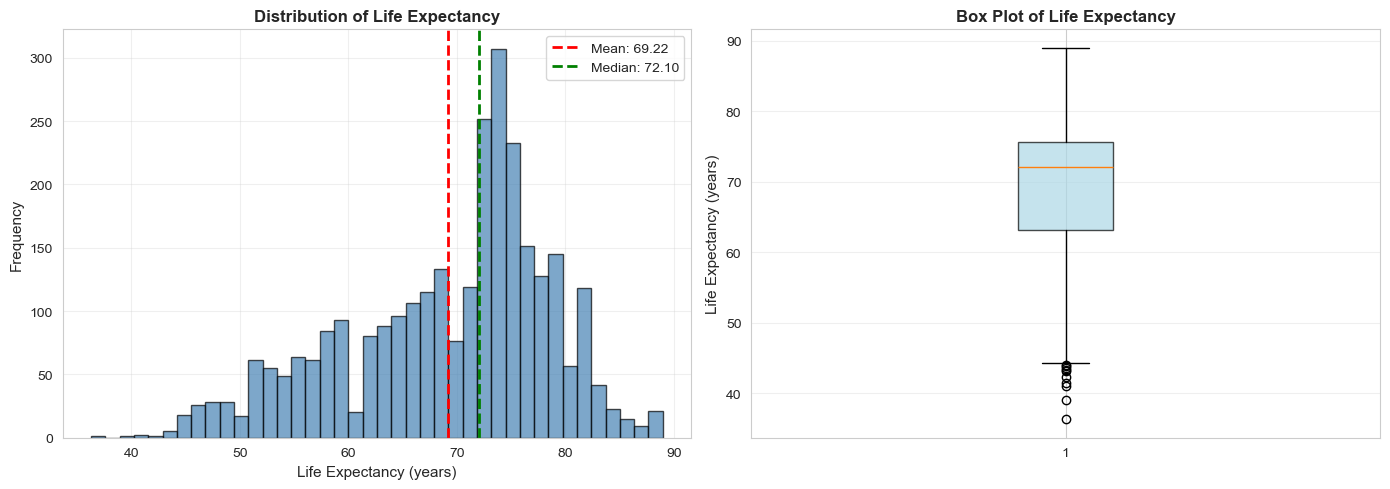

Life Expectancy - Detailed Statistics:

Mean:            69.22 years
Median:          72.10 years
Std Deviation:   9.52 years
Minimum:         36.30 years
25th Percentile: 63.10 years
75th Percentile: 75.70 years
Maximum:         89.00 years
Range:           52.70 years


In [7]:
# Visualize the target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Life expectancy '], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['Life expectancy '].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Life expectancy "].mean():.2f}')
axes[0].axvline(df['Life expectancy '].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Life expectancy "].median():.2f}')
axes[0].set_xlabel('Life Expectancy (years)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Life Expectancy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
box = axes[1].boxplot(df['Life expectancy '].dropna(), patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
box['boxes'][0].set_alpha(0.7)
axes[1].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[1].set_title('Box Plot of Life Expectancy', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("Life Expectancy - Detailed Statistics:")
print()
print(f"Mean:            {df['Life expectancy '].mean():.2f} years")
print(f"Median:          {df['Life expectancy '].median():.2f} years")
print(f"Std Deviation:   {df['Life expectancy '].std():.2f} years")
print(f"Minimum:         {df['Life expectancy '].min():.2f} years")
print(f"25th Percentile: {df['Life expectancy '].quantile(0.25):.2f} years")
print(f"75th Percentile: {df['Life expectancy '].quantile(0.75):.2f} years")
print(f"Maximum:         {df['Life expectancy '].max():.2f} years")
print(f"Range:           {df['Life expectancy '].max() - df['Life expectancy '].min():.2f} years")

### 4.2 Feature Relationships with Target

Explore how individual features relate to life expectancy using scatter plots to identify linear and non-linear patterns.

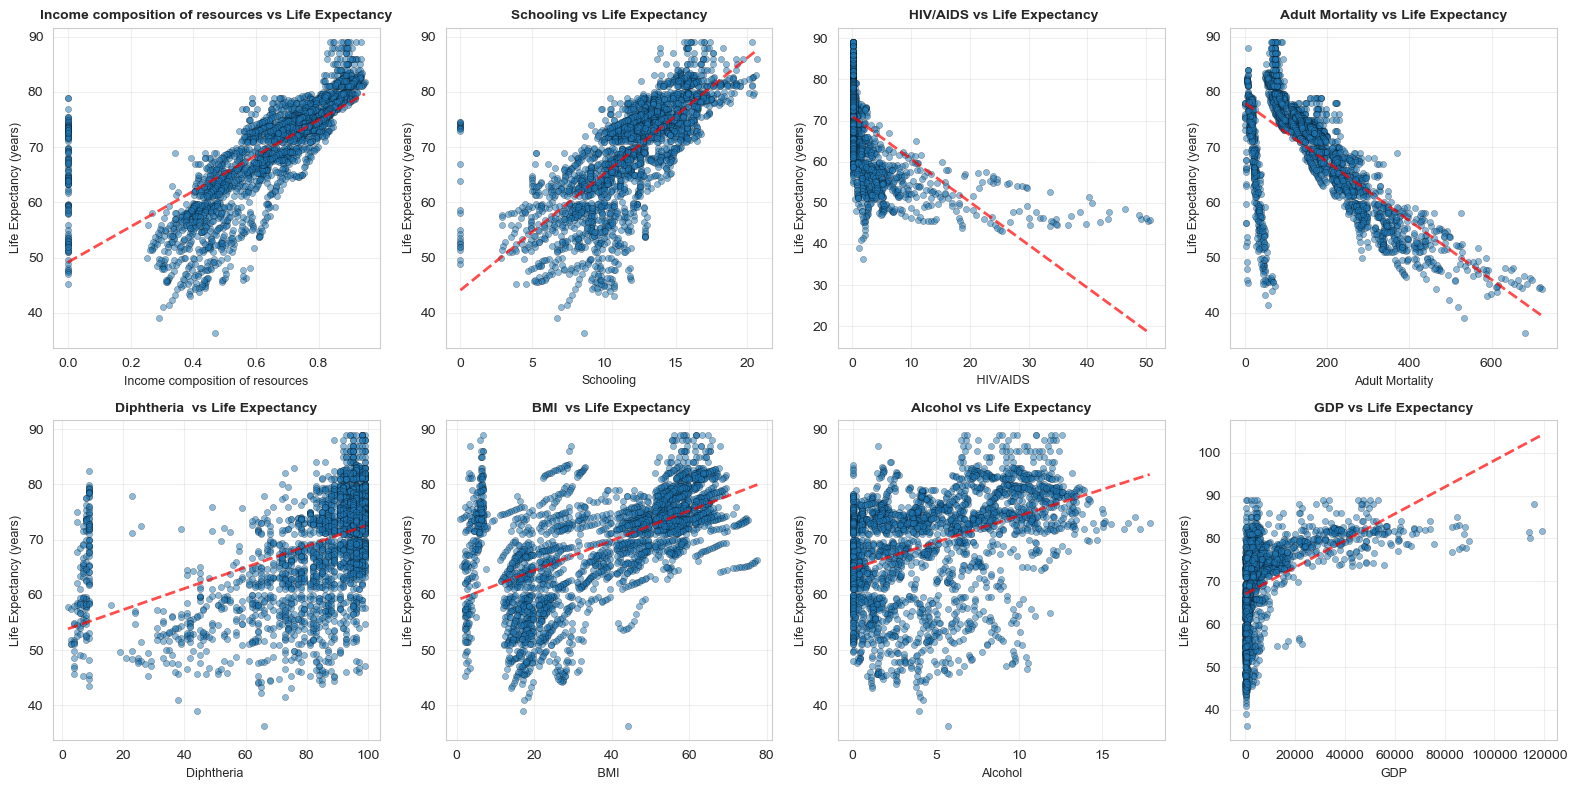

In [8]:
# Scatter plots: Features vs Life Expectancy
# Focus on most correlated features
important_features = ['Income composition of resources', 'Schooling', ' HIV/AIDS', 
                      'Adult Mortality', 'Diphtheria ', ' BMI ', 'Alcohol', 'GDP']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(important_features):
    axes[idx].scatter(df[feature], df['Life expectancy '], alpha=0.5, s=20, edgecolors='k', linewidths=0.3)
    axes[idx].set_xlabel(feature, fontsize=9)
    axes[idx].set_ylabel('Life Expectancy (years)', fontsize=9)
    axes[idx].set_title(f'{feature} vs Life Expectancy', fontsize=10, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    
    # Add trend line
    mask = ~(df[feature].isna() | df['Life expectancy '].isna())
    if mask.sum() > 0:
        z = np.polyfit(df[feature][mask], df['Life expectancy '][mask], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature][mask].min(), df[feature][mask].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.7)

plt.tight_layout()
plt.show()

### 4.3 Outlier Detection

Identify outliers using box plots to understand which features have extreme values that may need treatment.

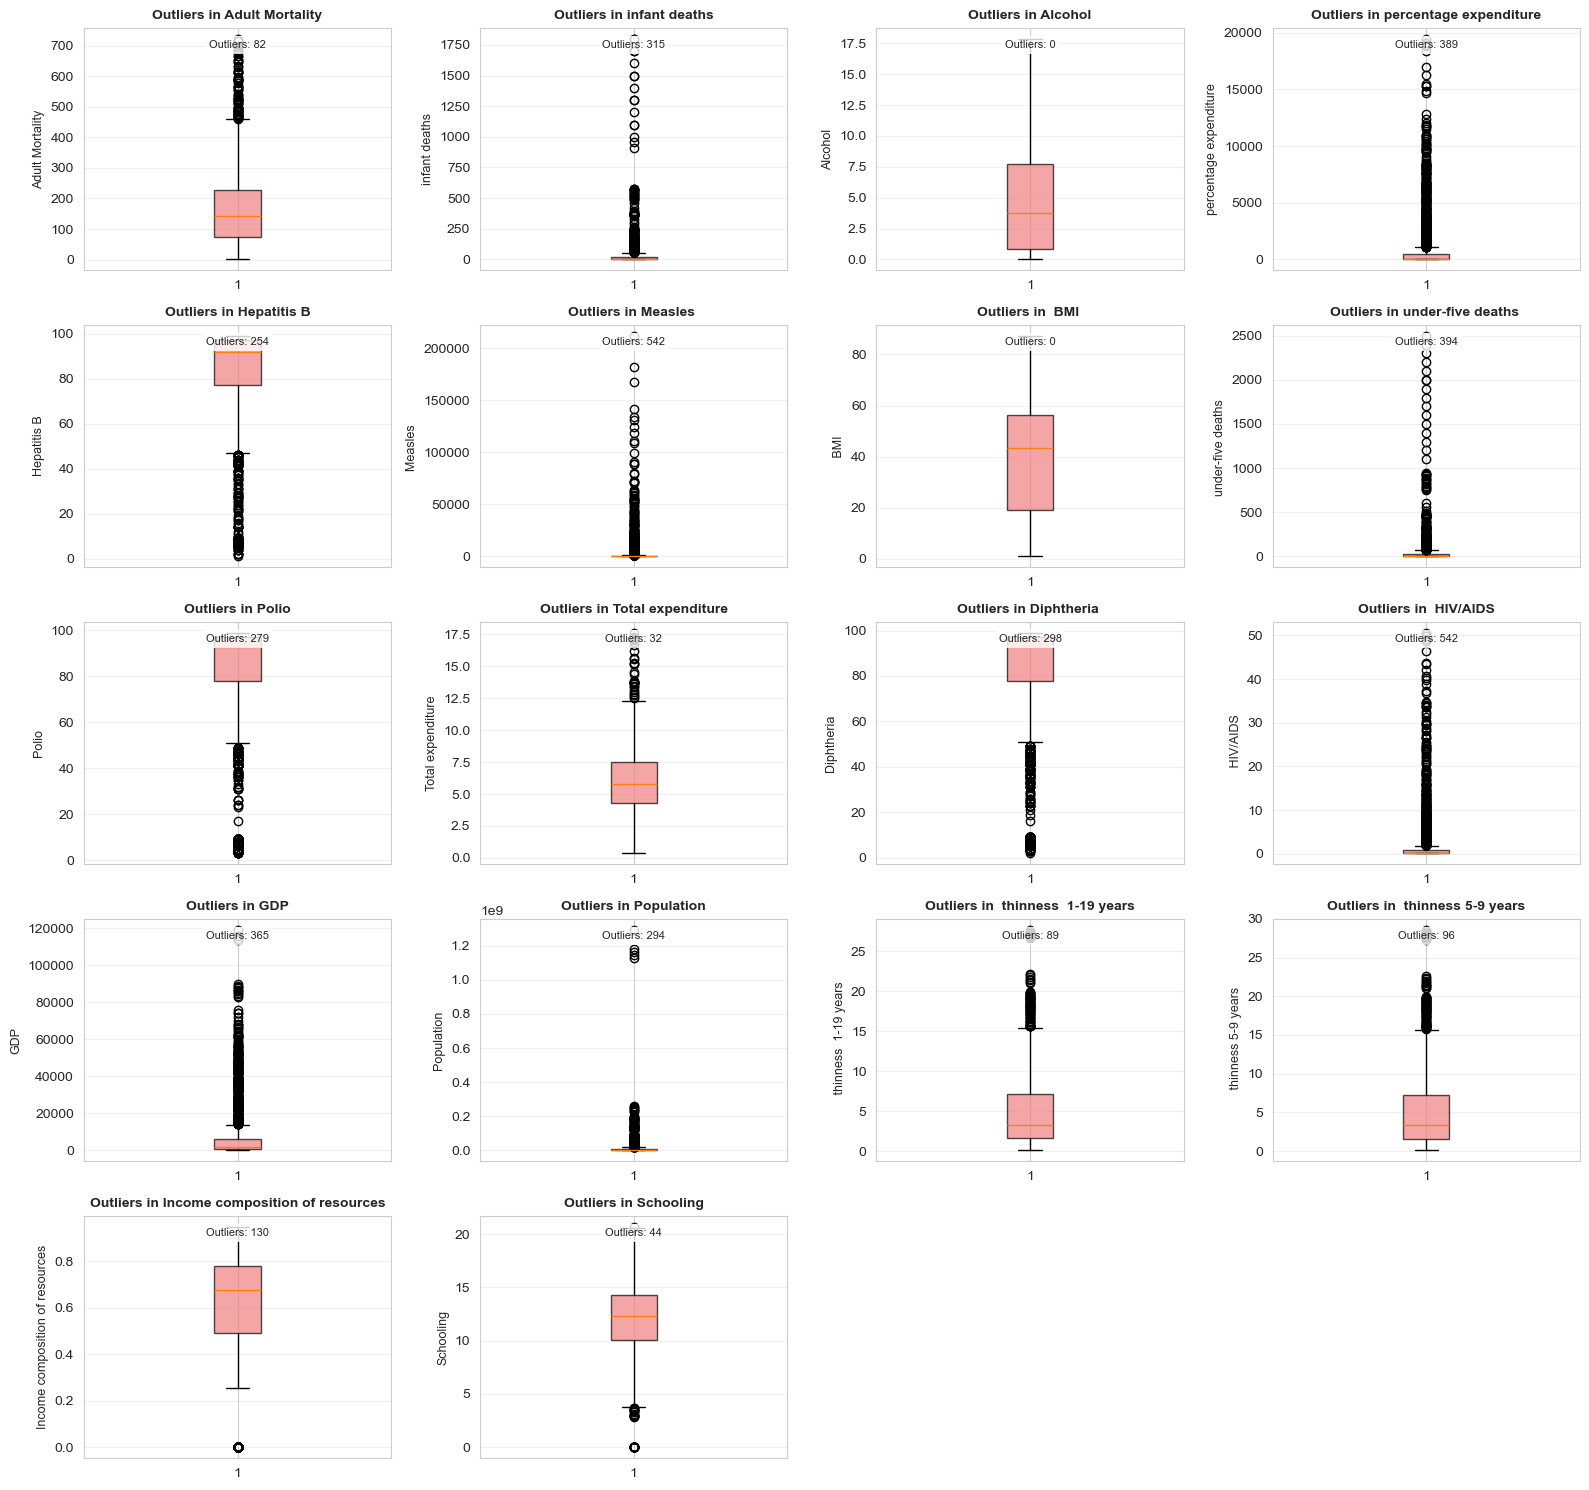

In [9]:
# Box plots for outlier detection
# Define key features for visualization
key_features = ['Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 
                'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 
                'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
                ' thinness  1-19 years', ' thinness 5-9 years', 
                'Income composition of resources', 'Schooling']

n_features = len(key_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    box = axes[idx].boxplot(df[feature].dropna(), patch_artist=True, vert=True)
    box['boxes'][0].set_facecolor('lightcoral')
    box['boxes'][0].set_alpha(0.7)
    axes[idx].set_ylabel(feature, fontsize=9)
    axes[idx].set_title(f'Outliers in {feature}', fontsize=10, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='y')
    
    # Calculate and display outlier count
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature].count()
    axes[idx].text(0.5, 0.95, f'Outliers: {outliers}', transform=axes[idx].transAxes,
                   ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide extra subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 4.4 Feature Distributions

Examine the distribution of all numerical features to understand their characteristics.

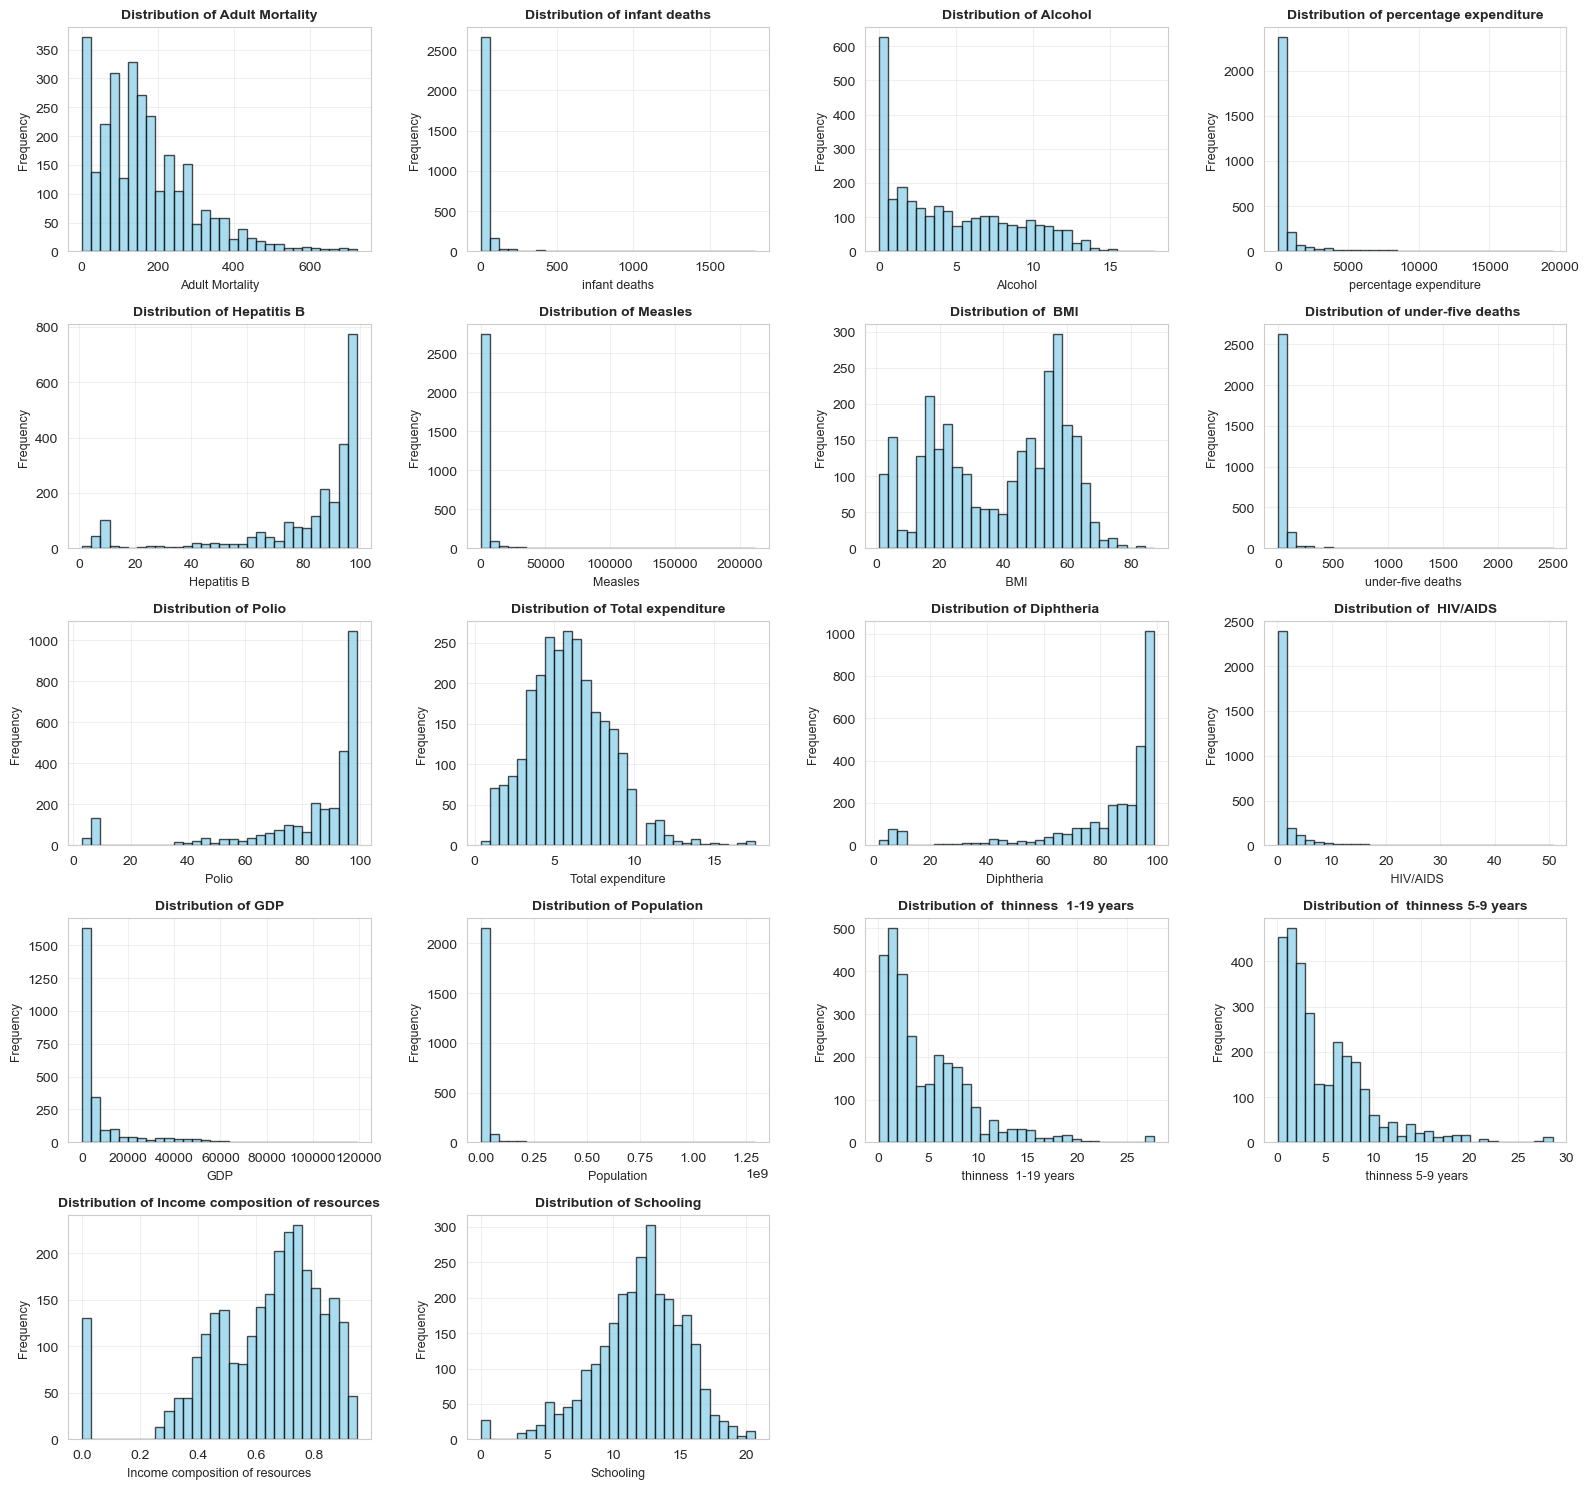

In [10]:
# Select key numerical features for visualization (excluding Year and target)
key_features = ['Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 
                'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 
                'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
                ' thinness  1-19 years', ' thinness 5-9 years', 
                'Income composition of resources', 'Schooling']

# Plot histograms for all numerical features
n_features = len(key_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df[feature].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_xlabel(feature, fontsize=9)
    axes[idx].set_ylabel('Frequency', fontsize=9)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=10, fontweight='bold')
    axes[idx].grid(alpha=0.3)

# Hide extra subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 4.5 Correlation Matrix Analysis

Examine correlations between features and the target variable using a heatmap to identify important relationships and detect multicollinearity.

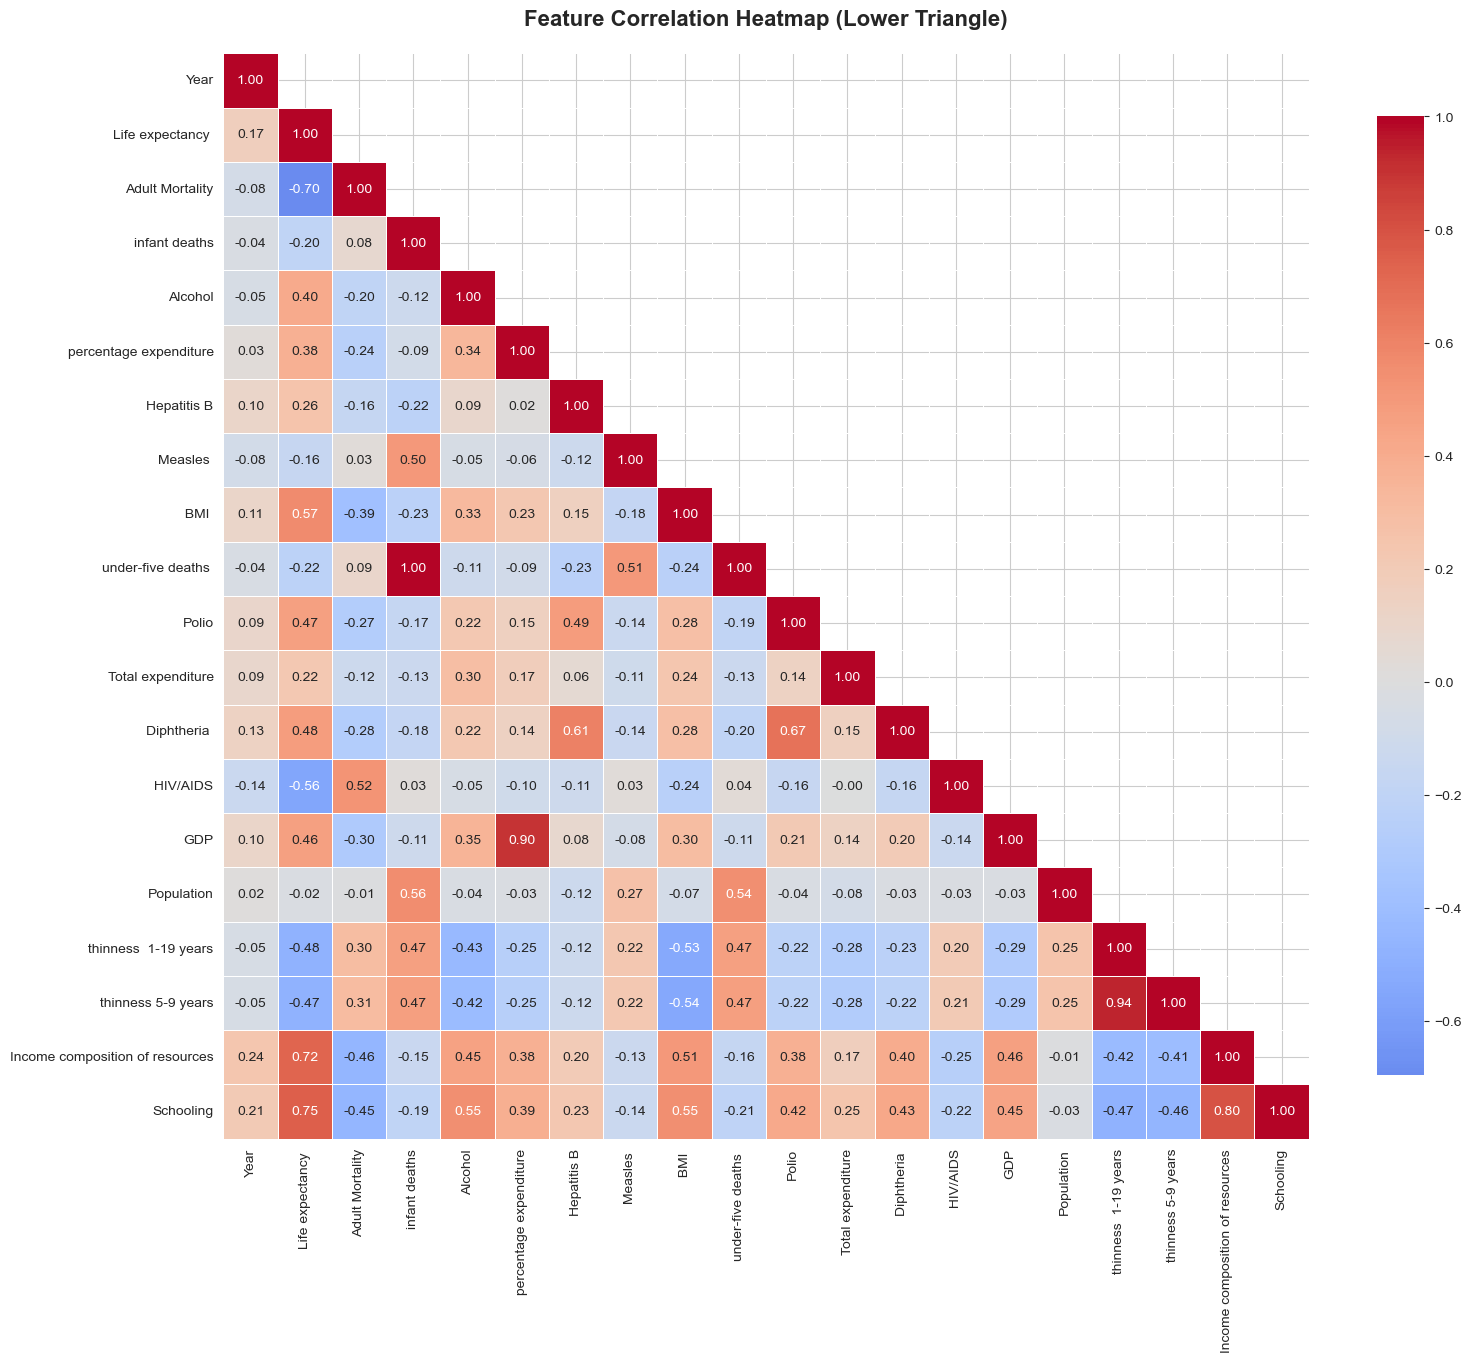


Correlations with Life Expectancy:

Feature                                  Correlation

Schooling                                    0.7520  (Very Strong)
Income composition of resources              0.7248  (Very Strong)
 BMI                                         0.5677  (Strong)
Diphtheria                                   0.4795  (Moderate)
Polio                                        0.4656  (Moderate)
GDP                                          0.4615  (Moderate)
Alcohol                                      0.4049  (Moderate)
percentage expenditure                       0.3819  (Moderate)
Hepatitis B                                  0.2568  (Weak)
Total expenditure                            0.2181  (Weak)
Year                                         0.1700  (Weak)
Population                                  -0.0215  (Weak)
Measles                                     -0.1576  (Weak)
infant deaths                               -0.1966  (Weak)
under-five deaths                

In [11]:
# Compute correlation matrix
correlation_matrix = df.select_dtypes(include='number').corr()

# Create a more readable heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, square=True)
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Display top correlations with Life Expectancy
life_exp_corr = correlation_matrix['Life expectancy '].sort_values(ascending=False)
print("\nCorrelations with Life Expectancy:")
print()
print(f"{'Feature':<40s} {'Correlation':>10s}")
print()
for feature, corr in life_exp_corr.items():
    if feature != 'Life expectancy ':
        correlation_strength = "Very Strong" if abs(corr) >= 0.7 else "Strong" if abs(corr) >= 0.5 else "Moderate" if abs(corr) >= 0.3 else "Weak"
        print(f"{feature:<40s} {corr:>10.4f}  ({correlation_strength})")

print()
print("Highly Correlated Feature Pairs (potential multicollinearity):")
print()
# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{feat1} <-> {feat2}: {corr:.4f}")
else:
    print("No feature pairs with correlation > 0.85 found")

## 5. Data Preprocessing

Clean and prepare the data for machine learning through a systematic approach:
1. Handle missing values using KNN imputation
2. Identify and treat outliers using IQR method
3. Encode categorical variables
4. Remove highly correlated features to reduce multicollinearity
5. Split data and normalize features

### 5.1 Handle Missing Values

Use KNN Imputation to fill missing values in numerical features based on similar samples.

**Method**: Each missing value is filled using the mean of 5 nearest neighbors

In [12]:
# Use KNN Imputer for numerical columns
imputer = KNNImputer(n_neighbors=5)
numerical_cols = df.select_dtypes(include='number').columns

print(f"Number of numerical features: {len(numerical_cols)}")
print(f"Total missing values before imputation: {df[numerical_cols].isnull().sum().sum()}")

df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

print(f"Total missing values after imputation: {df[numerical_cols].isnull().sum().sum()}")

Number of numerical features: 20
Total missing values before imputation: 2563
Total missing values after imputation: 0


### 5.2 Handle Outliers

Identify and cap outliers using the IQR (Interquartile Range) method. Extreme values are capped to reduce their impact on model training while preserving the overall data distribution.

In [13]:
# Function to cap outliers using IQR method
def cap_outliers(dataframe, column):
    """
    Cap outliers using the IQR (Interquartile Range) method.
    Values beyond 1.5 * IQR from Q1 and Q3 are capped to those bounds.
    """
    q1, q3 = np.percentile(dataframe[column], [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    # Count outliers before treatment
    outliers_count = ((dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)).sum()
    
    # Cap outliers
    dataframe[column] = np.where(dataframe[column] > upper_bound, upper_bound, dataframe[column])
    dataframe[column] = np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column])
    
    return dataframe, outliers_count

# Apply outlier capping to features with significant outliers
outlier_features = ["GDP", "Total expenditure", " thinness  1-19 years", 
                    " thinness 5-9 years", 'Income composition of resources', 'Schooling']

print(f"{'Feature':<35s} {'Outliers Treated':>15s}")
print()

for feature in outlier_features:
    df, outlier_count = cap_outliers(df, feature)
    print(f"{feature:<35s} {outlier_count:>15d}")

Feature                             Outliers Treated

GDP                                             411
Total expenditure                                37
 thinness  1-19 years                            89
 thinness 5-9 years                              99
Income composition of resources                 130
Schooling                                        46


### 5.2.1 Visualize Outlier Treatment Results

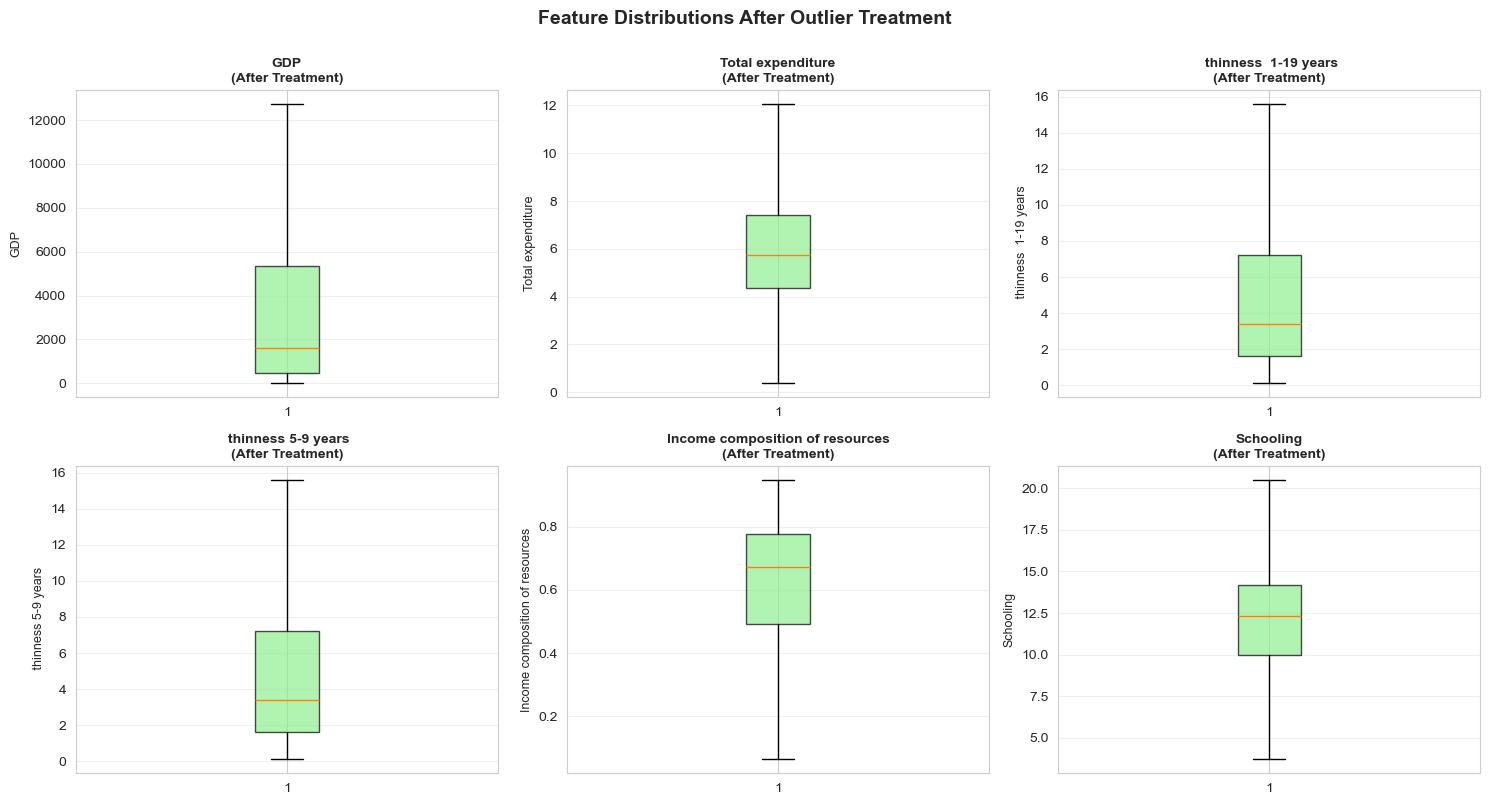

In [14]:
# Visualize distributions after outlier treatment
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(outlier_features):
    box = axes[idx].boxplot(df[feature].dropna(), patch_artist=True, vert=True)
    box['boxes'][0].set_facecolor('lightgreen')
    box['boxes'][0].set_alpha(0.7)
    axes[idx].set_ylabel(feature, fontsize=9)
    axes[idx].set_title(f'{feature}\n(After Treatment)', fontsize=10, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='y')

plt.suptitle('Feature Distributions After Outlier Treatment', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 5.3 Encode Categorical Variables

Use one-hot encoding to convert categorical variables (Country, Status) into numerical format. I drop the first category to avoid multicollinearity (dummy variable trap).

In [15]:
# One-hot encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical features found: {list(categorical_cols)}")

for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")

df_encoded = pd.get_dummies(df, columns=["Country", "Status"], drop_first=True)

print(f"\nDataset shape before encoding: {df.shape}")
print(f"Dataset shape after encoding: {df_encoded.shape}")
print(f"Number of features created: {df_encoded.shape[1] - df.shape[1]}")
print(f"Total features (excluding target): {df_encoded.shape[1] - 1}")

df_encoded.head()

Categorical features found: ['Country', 'Status']

Country: 193 unique values

Status: 2 unique values

Dataset shape before encoding: (2938, 22)
Dataset shape after encoding: (2938, 213)
Number of features created: 191
Total features (excluding target): 212


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,...,Country_United States of America,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe,Status_Developing
0,2015.0,65.0,263.0,62.0,0.01,71.279624,65.0,1154.0,19.1,83.0,...,False,False,False,False,False,False,False,False,False,True
1,2014.0,59.9,271.0,64.0,0.01,73.523582,62.0,492.0,18.6,86.0,...,False,False,False,False,False,False,False,False,False,True
2,2013.0,59.9,268.0,66.0,0.01,73.219243,64.0,430.0,18.1,89.0,...,False,False,False,False,False,False,False,False,False,True
3,2012.0,59.5,272.0,69.0,0.01,78.184215,67.0,2787.0,17.6,93.0,...,False,False,False,False,False,False,False,False,False,True
4,2011.0,59.2,275.0,71.0,0.01,7.097109,68.0,3013.0,17.2,97.0,...,False,False,False,False,False,False,False,False,False,True


### 5.4 Remove Highly Correlated Features

Remove features with high multicollinearity (correlation > 0.85 with other features) to reduce redundancy and improve model generalization. Features like 'under-five deaths' and 'infant deaths' are highly correlated, so I keep only the most informative ones.

- 'under-five deaths' is highly correlated with 'infant deaths' (>0.95)
- 'thinness 5-9 years' is highly correlated with 'thinness 1-19 years' (>0.92)
- 'percentage expenditure' has high correlation with GDP
- 'Schooling' is highly correlated with 'Income composition of resources'

In [16]:
# Remove highly correlated features to reduce multicollinearity
to_drop = ["under-five deaths ", "percentage expenditure", " thinness 5-9 years", "Schooling"]
df_encoded = df_encoded.drop(to_drop, axis=1)

print(f"\nDataset shape after feature removal: {df_encoded.shape}")
print(f"Remaining features (excluding target): {df_encoded.shape[1] - 1}")


Dataset shape after feature removal: (2938, 209)
Remaining features (excluding target): 208


## 6. Data Splitting and Normalization

Verify the final correlation structure after removing highly correlated features, then split the data into training, validation, and test sets and normalize features using MinMaxScaler.

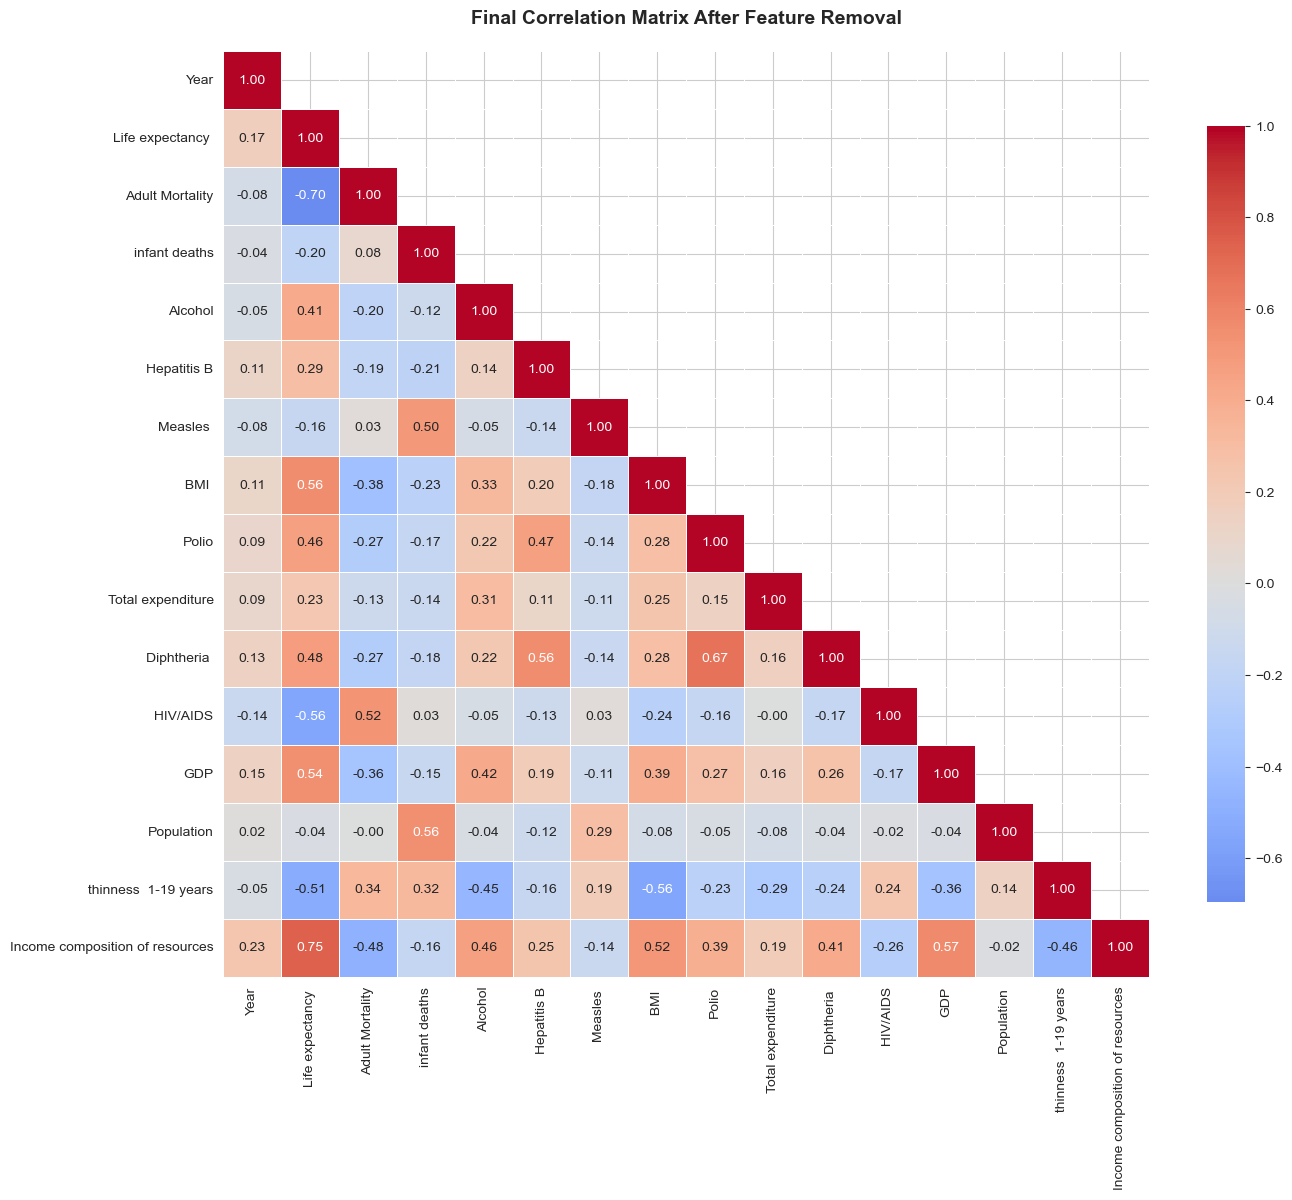


Checking for remaining high correlations (>0.85)...
  No feature pairs with correlation > 0.85 remain


In [17]:
# Visualize final correlation structure (numerical features only)
final_corr = df_encoded.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(final_corr, dtype=bool), k=1)
sns.heatmap(final_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, square=True)
plt.title('Final Correlation Matrix After Feature Removal', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Check for remaining high correlations
print("\nChecking for remaining high correlations (>0.85)...")
high_corr_found = False
for i in range(len(final_corr.columns)):
    for j in range(i+1, len(final_corr.columns)):
        if abs(final_corr.iloc[i, j]) > 0.85:
            print(f"  {final_corr.columns[i]} <-> {final_corr.columns[j]}: {final_corr.iloc[i, j]:.4f}")
            high_corr_found = True

if not high_corr_found:
    print("  No feature pairs with correlation > 0.85 remain")

In [18]:
# Separate features and target
X = df_encoded.drop("Life expectancy ", axis=1)
y = df_encoded["Life expectancy "]

# Split: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

print(f"Training set:   {X_train.shape[0]:>5d} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:>5d} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:>5d} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nNumber of features: {X_train.shape[1]}")

print("\nTarget variable statistics per set:")
print()
print(f"{'Set':<15s} {'Mean':>10s} {'Std':>10s} {'Min':>10s} {'Max':>10s}")
print()
print(f"{'Training':<15s} {y_train.mean():>10.2f} {y_train.std():>10.2f} {y_train.min():>10.2f} {y_train.max():>10.2f}")
print(f"{'Validation':<15s} {y_val.mean():>10.2f} {y_val.std():>10.2f} {y_val.min():>10.2f} {y_val.max():>10.2f}")
print(f"{'Test':<15s} {y_test.mean():>10.2f} {y_test.std():>10.2f} {y_test.min():>10.2f} {y_test.max():>10.2f}")

Training set:    1762 samples (60.0%)
Validation set:   588 samples (20.0%)
Test set:         588 samples (20.0%)

Number of features: 208

Target variable statistics per set:

Set                   Mean        Std        Min        Max

Training             69.46       9.59      36.30      89.00
Validation           68.79       9.47      43.10      89.00
Test                 69.02       9.32      43.80      89.00


In [19]:
# Normalize features using MinMaxScaler (scales to [0, 1]) to ensures all features contribute equally
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaling statistics:")
print(f"  Feature range before scaling: [{X_train.min().min():.2f}, {X_train.max().max():.2f}]")
print(f"  Feature range after scaling:  [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")


Scaling statistics:
  Feature range before scaling: [0.00, 1293859294.00]
  Feature range after scaling:  [0.00, 1.00]


## 7. Dimensionality Reduction

I reduce the dimensionality of the dataset using two approaches:
1. **PCA (Principal Component Analysis)** - Linear transformation
2. **Autoencoder** - Non-linear neural network-based transformation

Both methods reduce the data to the **same number of dimensions** for fair comparison.

### 7.1 PCA (Principal Component Analysis)

Apply PCA to find the optimal number of components that retain 90% and 95% of the variance.

Original number of features: 208
Components needed for 90% variance: 145
Components needed for 95% variance: 166
Variance explained by 145 components: 90.11%
Variance explained by 166 components: 95.19%


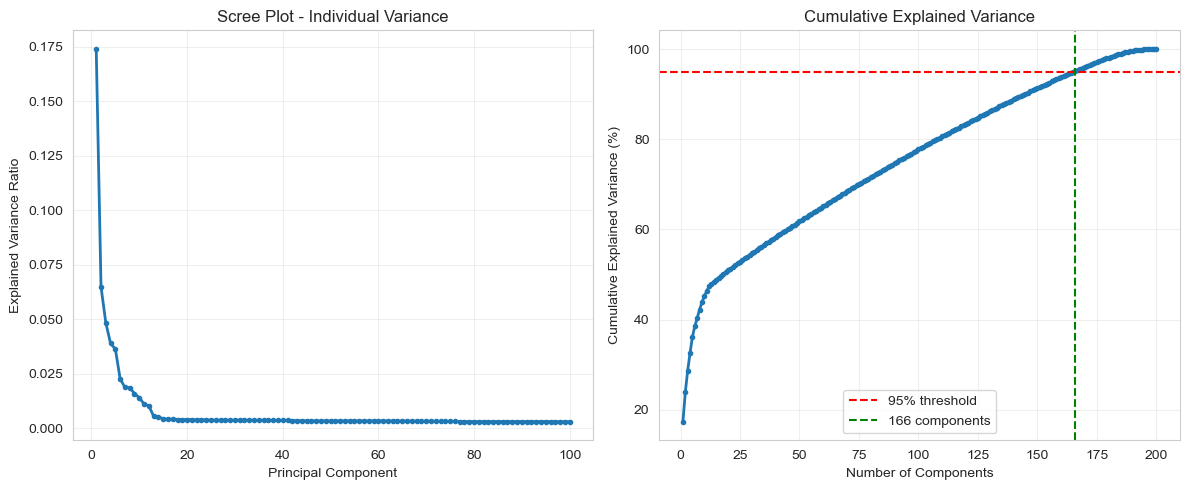

In [20]:
# First, determine optimal number of components
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Variance explained by {n_components_90} components: {cumulative_variance[n_components_90-1]*100:.2f}%")
print(f"Variance explained by {n_components_95} components: {cumulative_variance[n_components_95-1]*100:.2f}%")

# Plot explained variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Show more components or all of them
plot_limit = min(len(pca_full.explained_variance_ratio_), 100)  # Increased to 100
plt.plot(range(1, plot_limit + 1), 
         pca_full.explained_variance_ratio_[:plot_limit], 'o-', linewidth=2, markersize=3)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Individual Variance')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plot_limit = min(len(cumulative_variance), 200)  # Show up to 200 components
plt.plot(range(1, plot_limit + 1), 
         cumulative_variance[:plot_limit] * 100, 'o-', linewidth=2, markersize=3)
plt.axhline(y=95, color='r', linestyle='--', label='95% threshold')
if n_components_95 <= plot_limit:  # Adjusted condition
    plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Apply PCA with optimal number of components
TARGET_DIM = 145  # This will be used for both PCA and Autoencoder

# Time PCA fitting
pca_start_time = time.time()
pca = PCA(n_components=TARGET_DIM)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_time = time.time() - pca_start_time

print(f"Reduced dimensions: {TARGET_DIM}")
print(f"PCA fitting time: {pca_time:.4f} seconds")
print(f"Total variance retained: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

print(f"Training set shape: {X_train_pca.shape}")
print(f"\nDimensionality reduction: {X_train_scaled.shape[1]} → {TARGET_DIM} ({TARGET_DIM/X_train_scaled.shape[1]*100:.1f}% retained)")

print(f"Validation set shape: {X_val_pca.shape}")
print(f"Test set shape: {X_test_pca.shape}")

Reduced dimensions: 145
PCA fitting time: 3.9825 seconds
Total variance retained: 89.63%
Training set shape: (1762, 145)

Dimensionality reduction: 208 → 145 (69.7% retained)
Validation set shape: (588, 145)
Test set shape: (588, 145)


### 7.2 Autoencoder for Dimensionality Reduction

Build and train an autoencoder neural network to learn a compressed representation of the data with the same dimensionality as PCA.

In [22]:
# Define Autoencoder architecture with batch normalization
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder: Batch normalization for stable training
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, encoding_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        return self.encoder(x)

# Initialize autoencoder (using global device variable)
input_dim = X_train_scaled.shape[1]
encoding_dim = TARGET_DIM  # Same as PCA

autoencoder = Autoencoder(input_dim, encoding_dim).to(device)
print(f"Autoencoder initialized: {input_dim} → {encoding_dim} → {input_dim}")
print(f"Total parameters: {sum(p.numel() for p in autoencoder.parameters()):,}")

Autoencoder initialized: 208 → 145 → 208
Total parameters: 89,697


In [ ]:
# Train the improved autoencoder with learning rate scheduling
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001, weight_decay=1e-4)

# Add learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5, verbose=True)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)

# Training loop
num_epochs = 150
batch_size = 32
train_losses = []
val_losses = []

# Early stopping parameters
best_val_loss = float('inf')
patience = 20
patience_counter = 0
best_model_state = None

print("Training Autoencoder with Learning Rate Scheduling and Early Stopping...")
print()

# Start timing
autoencoder_start_time = time.time()

for epoch in range(num_epochs):
    autoencoder.train()
    epoch_loss = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch = X_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs = autoencoder(batch)
        loss = criterion(outputs, batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Validation
    autoencoder.eval()
    with torch.no_grad():
        val_outputs = autoencoder(X_val_tensor)
        val_loss = criterion(val_outputs, X_val_tensor).item()
    
    train_losses.append(epoch_loss / (len(X_train_tensor) // batch_size + 1))
    val_losses.append(val_loss)
    
    # Step the scheduler based on validation loss
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = autoencoder.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.6f}, Val Loss: {val_loss:.6f}, LR: {current_lr:.6f}')
    
    if patience_counter >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

# Restore best model
if best_model_state is not None:
    autoencoder.load_state_dict(best_model_state)
    print(f'Restored best model with validation loss: {best_val_loss:.6f}')

# Capture training time
autoencoder_training_time = time.time() - autoencoder_start_time
print()
print(f"Autoencoder training time: {autoencoder_training_time:.2f} seconds")
print()
print(f"Training complete. Final Val Loss: {val_losses[-1]:.6f}")

Training Autoencoder with Learning Rate Scheduling and Early Stopping...

Epoch [10/150], Train Loss: 0.005694, Val Loss: 0.005680, LR: 0.001000
Epoch [20/150], Train Loss: 0.004416, Val Loss: 0.004691, LR: 0.001000
Epoch [30/150], Train Loss: 0.004119, Val Loss: 0.004549, LR: 0.001000
Epoch [40/150], Train Loss: 0.004114, Val Loss: 0.004631, LR: 0.001000
Epoch [50/150], Train Loss: 0.003460, Val Loss: 0.004173, LR: 0.000500
Epoch [60/150], Train Loss: 0.003453, Val Loss: 0.003930, LR: 0.000500
Epoch [70/150], Train Loss: 0.003154, Val Loss: 0.003756, LR: 0.000500
Epoch [80/150], Train Loss: 0.003334, Val Loss: 0.003918, LR: 0.000250
Epoch [90/150], Train Loss: 0.002809, Val Loss: 0.003528, LR: 0.000250
Epoch [100/150], Train Loss: 0.002745, Val Loss: 0.003418, LR: 0.000250
Epoch [110/150], Train Loss: 0.002687, Val Loss: 0.003308, LR: 0.000250
Epoch [120/150], Train Loss: 0.002614, Val Loss: 0.003263, LR: 0.000250
Epoch [130/150], Train Loss: 0.002599, Val Loss: 0.003260, LR: 0.000250

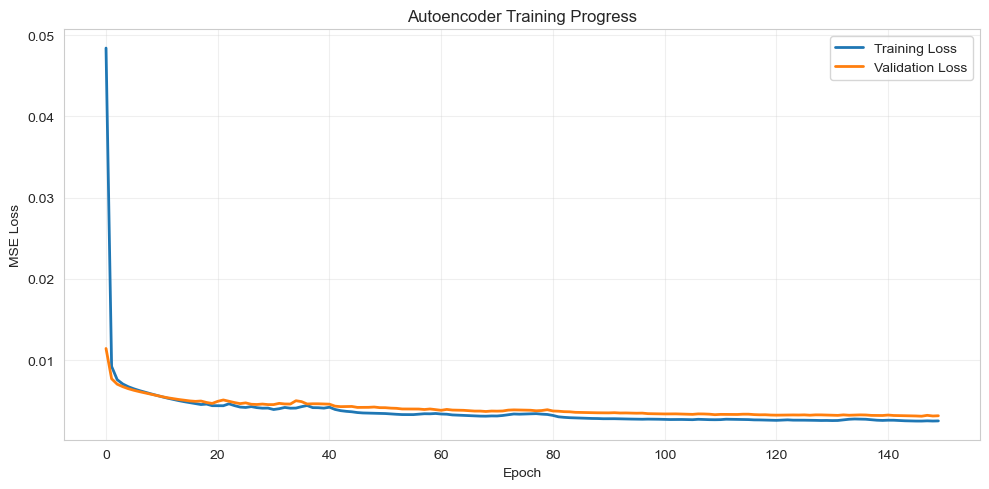

In [24]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Progress')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Extract encoded representations
autoencoder.eval()
with torch.no_grad():
    X_train_ae = autoencoder.encode(X_train_tensor).cpu().numpy()
    X_val_ae = autoencoder.encode(X_val_tensor).cpu().numpy()
    X_test_ae = autoencoder.encode(torch.FloatTensor(X_test_scaled).to(device)).cpu().numpy()

print(f"Encoded dimensions: {TARGET_DIM}")
print(f"Training set shape: {X_train_ae.shape}")
print(f"Validation set shape: {X_val_ae.shape}")
print(f"Test set shape: {X_test_ae.shape}")

Encoded dimensions: 145
Training set shape: (1762, 145)
Validation set shape: (588, 145)
Test set shape: (588, 145)


## 8. Feedforward Neural Network (FNN) for Regression

Define a flexible FNN architecture for regression that can work with different input dimensions.

In [26]:
# Define FNN for regression
class FNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32, 16], dropout_rate=0.1):
        """
        Feedforward Neural Network for Regression
        
        Args:
            input_dim: Number of input features
            hidden_dims: List of hidden layer sizes
            dropout_rate: Dropout probability for regularization (reduced to prevent underfitting)
        """
        super(FNN, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Build hidden layers
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # Output layer (single neuron for regression)
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [27]:
# Training function for FNN with learning rate scheduling
def train_fnn(model, X_train, y_train, X_val, y_val, num_epochs=200, batch_size=32, lr=0.001, weight_decay=1e-4):
    """
    Train a Feedforward Neural Network with early stopping and learning rate scheduling.
    
    Args:
        model: FNN model to train
        X_train, y_train: Training data
        X_val, y_val: Validation data
        num_epochs: Maximum number of training epochs
        batch_size: Mini-batch size
        lr: Learning rate
        weight_decay: L2 regularization strength (default: 1e-4)
    
    Returns:
        model: Trained model
        history: Dictionary containing training history
        training_time: Time taken to train (seconds)
    """
    # Use global device variable
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5, verbose=False)
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1).to(device)
    
    # Training history
    history = {'train_loss': [], 'val_loss': [], 'learning_rates': []}
    
    # Early stopping parameters
    best_val_loss = float('inf')
    patience = 20
    patience_counter = 0
    best_model_state = None
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        n_samples = 0
        
        # Mini-batch training
        for i in range(0, len(X_train_tensor), batch_size):
            batch_X = X_train_tensor[i:i+batch_size]
            batch_y = y_train_tensor[i:i+batch_size]
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * len(batch_X)
            n_samples += len(batch_X)
        
        # Compute training loss properly (also in eval mode for fair comparison)
        model.eval()
        with torch.no_grad():
            train_outputs = model(X_train_tensor)
            train_loss = criterion(train_outputs, y_train_tensor).item()
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor).item()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['learning_rates'].append(optimizer.param_groups[0]['lr'])
        
        # Step the scheduler
        scheduler.step(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    training_time = time.time() - start_time
    
    return model, history, training_time

## 9. Model Training on Three Datasets

Train FNN models on:
1. Original scaled dataset
2. PCA-reduced dataset
3. Autoencoder-reduced dataset

Compare training time and performance across all three approaches.

### 9.0 Hyperparameter Tuning via Cross-Validation

I use K-Fold Cross-Validation to find optimal hyperparameters (learning rate, batch size, hidden layer configuration) for the FNN models.

In [ ]:
def cross_validate_fnn(X, y, input_dim, hidden_dims, lr, batch_size, n_folds=5, num_epochs=50):
    """
    Perform K-Fold Cross-Validation for FNN hyperparameter tuning.
    
    Returns:
        mean_val_loss: Average validation loss across folds
        std_val_loss: Standard deviation of validation loss
    """
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_val_losses = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
        # Split data
        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]
        y_train_fold = pd.Series(y.values[train_idx])
        y_val_fold = pd.Series(y.values[val_idx])
        
        # Create model
        model = FNN(input_dim=input_dim, hidden_dims=hidden_dims, dropout_rate=0.1).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        
        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train_fold).to(device)
        y_train_tensor = torch.FloatTensor(y_train_fold.values).reshape(-1, 1).to(device)
        X_val_tensor = torch.FloatTensor(X_val_fold).to(device)
        y_val_tensor = torch.FloatTensor(y_val_fold.values).reshape(-1, 1).to(device)
        
        # Training loop (simplified for CV)
        for epoch in range(num_epochs):
            model.train()
            for i in range(0, len(X_train_tensor), batch_size):
                batch_X = X_train_tensor[i:i+batch_size]
                batch_y = y_train_tensor[i:i+batch_size]
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        
        # Evaluate on validation fold
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor).item()
        
        fold_val_losses.append(val_loss)
    
    return np.mean(fold_val_losses), np.std(fold_val_losses)

# Define hyperparameter grid
param_grid = {
    'hidden_dims': [[64, 32, 16], [128, 64, 32], [32, 16, 8]],
    'learning_rate': [0.001, 0.0005, 0.01],
    'batch_size': [32, 64]
}

print("HYPERPARAMETER TUNING VIA 5-FOLD CROSS-VALIDATION")
print()
print("Testing configurations on original dataset...")
print()

best_config = None
best_val_loss = float('inf')
results = []

# Test subset of configurations for efficiency
test_configs = [
    {'hidden_dims': [64, 32, 16], 'lr': 0.001, 'batch_size': 32},
    {'hidden_dims': [128, 64, 32], 'lr': 0.001, 'batch_size': 32},
    {'hidden_dims': [32, 16, 8], 'lr': 0.001, 'batch_size': 32},
    {'hidden_dims': [64, 32, 16], 'lr': 0.0005, 'batch_size': 32},
    {'hidden_dims': [64, 32, 16], 'lr': 0.001, 'batch_size': 64},
]

for config in test_configs:
    mean_loss, std_loss = cross_validate_fnn(
        X_train_scaled, y_train, 
        input_dim=X_train_scaled.shape[1],
        hidden_dims=config['hidden_dims'],
        lr=config['lr'],
        batch_size=config['batch_size'],
        n_folds=5,
        num_epochs=50
    )
    
    results.append({
        'hidden_dims': str(config['hidden_dims']),
        'lr': config['lr'],
        'batch_size': config['batch_size'],
        'mean_val_loss': mean_loss,
        'std_val_loss': std_loss
    })
    
    if mean_loss < best_val_loss:
        best_val_loss = mean_loss
        best_config = config
    
    print(f"Config: hidden={config['hidden_dims']}, lr={config['lr']}, batch={config['batch_size']}")
    print(f"  → Mean Val Loss: {mean_loss:.4f} ± {std_loss:.4f}")

print()
print("BEST CONFIGURATION:")
print(f"  Hidden layers: {best_config['hidden_dims']}")
print(f"  Learning rate: {best_config['lr']}")
print(f"  Batch size: {best_config['batch_size']}")
print(f"  CV Validation Loss: {best_val_loss:.4f}")

# Store best hyperparameters for use in training
BEST_HIDDEN_DIMS = best_config['hidden_dims']
BEST_LR = best_config['lr']
BEST_BATCH_SIZE = best_config['batch_size']

HYPERPARAMETER TUNING VIA 5-FOLD CROSS-VALIDATION

Testing configurations on original dataset...

Config: hidden=[64, 32, 16], lr=0.001, batch=32
  → Mean Val Loss: 13.8246 ± 2.0007
Config: hidden=[128, 64, 32], lr=0.001, batch=32
  → Mean Val Loss: 10.0785 ± 1.3708
Config: hidden=[32, 16, 8], lr=0.001, batch=32
  → Mean Val Loss: 28.0364 ± 4.7537
Config: hidden=[64, 32, 16], lr=0.0005, batch=32
  → Mean Val Loss: 25.6441 ± 1.1686
Config: hidden=[64, 32, 16], lr=0.001, batch=64
  → Mean Val Loss: 25.3773 ± 2.6741

BEST CONFIGURATION:
  Hidden layers: [128, 64, 32]
  Learning rate: 0.001
  Batch size: 32
  CV Validation Loss: 10.0785


### 9.1 Train FNN on Original Dataset

In [29]:
# Initialize and train FNN on original dataset using best hyperparameters from CV
print("\nTRAINING ON ORIGINAL DATASET")
print(f"Using CV-tuned hyperparameters: hidden={BEST_HIDDEN_DIMS}, lr={BEST_LR}, batch={BEST_BATCH_SIZE}")
print()

input_dim_original = X_train_scaled.shape[1]
fnn_original = FNN(input_dim=input_dim_original, hidden_dims=BEST_HIDDEN_DIMS)

print(f"Input dimensions: {input_dim_original}")
print("Training...")

fnn_original, history_original, time_original = train_fnn(
    fnn_original, X_train_scaled, y_train, X_val_scaled, y_val, 
    num_epochs=200, batch_size=BEST_BATCH_SIZE, lr=BEST_LR
)

print(f"\nTraining completed in {time_original:.2f} seconds")
print(f"Final Training Loss: {history_original['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_original['val_loss'][-1]:.4f}")


TRAINING ON ORIGINAL DATASET
Using CV-tuned hyperparameters: hidden=[128, 64, 32], lr=0.001, batch=32

Input dimensions: 208
Training...
Epoch [1/200], Train Loss: 2799.8279, Val Loss: 2737.3621, LR: 0.001000
Epoch [10/200], Train Loss: 21.3676, Val Loss: 24.8828, LR: 0.001000
Epoch [20/200], Train Loss: 14.7626, Val Loss: 16.6552, LR: 0.001000
Epoch [30/200], Train Loss: 13.5363, Val Loss: 14.4918, LR: 0.001000
Epoch [40/200], Train Loss: 6.8838, Val Loss: 7.7870, LR: 0.001000
Epoch [50/200], Train Loss: 11.8900, Val Loss: 13.0650, LR: 0.001000
Epoch [60/200], Train Loss: 11.5552, Val Loss: 12.4443, LR: 0.001000
Epoch [70/200], Train Loss: 6.0707, Val Loss: 7.0570, LR: 0.001000
Epoch [80/200], Train Loss: 3.6507, Val Loss: 4.4985, LR: 0.000500
Epoch [90/200], Train Loss: 5.0480, Val Loss: 5.9044, LR: 0.000500
Epoch [100/200], Train Loss: 3.5561, Val Loss: 4.6329, LR: 0.000500
Epoch [110/200], Train Loss: 4.7982, Val Loss: 5.7812, LR: 0.000250
Epoch [120/200], Train Loss: 3.2055, Val 

### 9.2 Train FNN on PCA-Reduced Dataset

In [30]:
# Initialize and train FNN on PCA-reduced dataset using best hyperparameters from CV
print("\nTRAINING ON PCA-REDUCED DATASET")
print(f"Using CV-tuned hyperparameters: lr={BEST_LR}, batch={BEST_BATCH_SIZE}")
print()

# Use smaller architecture for reduced dimensions
input_dim_pca = X_train_pca.shape[1]
fnn_pca = FNN(input_dim=input_dim_pca, hidden_dims=[32, 16, 8])

print(f"Input dimensions: {input_dim_pca}")
print("Training...")

fnn_pca, history_pca, time_pca = train_fnn(
    fnn_pca, X_train_pca, y_train, X_val_pca, y_val,
    num_epochs=200, batch_size=BEST_BATCH_SIZE, lr=BEST_LR
)

print(f"\nTraining completed in {time_pca:.2f} seconds")
print(f"Final Training Loss: {history_pca['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_pca['val_loss'][-1]:.4f}")


TRAINING ON PCA-REDUCED DATASET
Using CV-tuned hyperparameters: lr=0.001, batch=32

Input dimensions: 145
Training...
Epoch [1/200], Train Loss: 4876.0444, Val Loss: 4781.7764, LR: 0.001000
Epoch [10/200], Train Loss: 19.6343, Val Loss: 20.4061, LR: 0.001000
Epoch [20/200], Train Loss: 16.7724, Val Loss: 18.0359, LR: 0.001000
Epoch [30/200], Train Loss: 21.6161, Val Loss: 21.6855, LR: 0.000500
Epoch [40/200], Train Loss: 14.2637, Val Loss: 14.8262, LR: 0.000500
Epoch [50/200], Train Loss: 16.3616, Val Loss: 17.0763, LR: 0.000500
Epoch [60/200], Train Loss: 14.6146, Val Loss: 16.2888, LR: 0.000250
Early stopping at epoch 67

Training completed in 22.03 seconds
Final Training Loss: 14.2924
Final Validation Loss: 16.3647


### 9.3 Train FNN on Autoencoder-Reduced Dataset

In [31]:
# Initialize and train FNN on Autoencoder-reduced dataset using best hyperparameters from CV
print("\nTRAINING ON AUTOENCODER-REDUCED DATASET")
print(f"Using CV-tuned hyperparameters: lr={BEST_LR}, batch={BEST_BATCH_SIZE}")
print()

input_dim_ae = X_train_ae.shape[1]
fnn_ae = FNN(input_dim=input_dim_ae, hidden_dims=[32, 16, 8])

print(f"Input dimensions: {input_dim_ae}")
print("Training...")

fnn_ae, history_ae, time_ae = train_fnn(
    fnn_ae, X_train_ae, y_train, X_val_ae, y_val,
    num_epochs=200, batch_size=BEST_BATCH_SIZE, lr=BEST_LR
)

print(f"\nTraining completed in {time_ae:.2f} seconds")
print(f"Final Training Loss: {history_ae['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_ae['val_loss'][-1]:.4f}")


TRAINING ON AUTOENCODER-REDUCED DATASET
Using CV-tuned hyperparameters: lr=0.001, batch=32

Input dimensions: 145
Training...
Epoch [1/200], Train Loss: 4869.2544, Val Loss: 4774.9302, LR: 0.001000
Epoch [10/200], Train Loss: 107.5478, Val Loss: 105.9316, LR: 0.001000
Epoch [20/200], Train Loss: 59.7724, Val Loss: 59.6839, LR: 0.001000
Epoch [30/200], Train Loss: 47.1204, Val Loss: 46.9786, LR: 0.001000
Epoch [40/200], Train Loss: 32.0411, Val Loss: 31.0548, LR: 0.001000
Epoch [50/200], Train Loss: 29.8802, Val Loss: 28.9145, LR: 0.001000
Epoch [60/200], Train Loss: 33.4333, Val Loss: 32.8503, LR: 0.001000
Epoch [70/200], Train Loss: 29.5793, Val Loss: 29.0012, LR: 0.001000
Epoch [80/200], Train Loss: 22.6604, Val Loss: 21.7226, LR: 0.000500
Epoch [90/200], Train Loss: 23.3889, Val Loss: 22.6166, LR: 0.000500
Epoch [100/200], Train Loss: 23.2321, Val Loss: 22.3948, LR: 0.000250
Early stopping at epoch 106

Training completed in 34.95 seconds
Final Training Loss: 22.7631
Final Validati

## 10. Model Evaluation and Comparison

Evaluate all three models on the test set using regression-appropriate metrics and compare their performance.

I use standard regression metrics:
- **MSE (Mean Squared Error)**: Average of squared differences between predictions and actual values
- **RMSE (Root Mean Squared Error)**: Square root of MSE, in the same units as the target
- **MAE (Mean Absolute Error)**: Average of absolute differences
- **R² Score**: Proportion of variance explained by the model (1.0 = perfect fit)

In [ ]:
# Evaluation function
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained model on test data
    
    Returns:
        predictions: Model predictions
        metrics: Dictionary of evaluation metrics
    """
    # Use global device variable
    model.eval()
    
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    
    with torch.no_grad():
        predictions = model(X_test_tensor).cpu().numpy().flatten()
    
    # Calculate metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    metrics = {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2
    }
    
    return predictions, metrics

### 10.1 Evaluate All Models

In [33]:
# Evaluate all three models
print("\nMODEL EVALUATION ON TEST SET")
print()

# Evaluate Original Dataset Model
pred_original, metrics_original = evaluate_model(fnn_original, X_test_scaled, y_test, "Original Dataset")
print(f"\n1. {metrics_original['Model']}")
for key, value in metrics_original.items():
    if key != 'Model':
        print(f"   {key}: {value:.4f}")

# Evaluate PCA Model
pred_pca, metrics_pca = evaluate_model(fnn_pca, X_test_pca, y_test, "PCA-Reduced Dataset")
print(f"\n2. {metrics_pca['Model']}")
for key, value in metrics_pca.items():
    if key != 'Model':
        print(f"   {key}: {value:.4f}")

# Evaluate Autoencoder Model
pred_ae, metrics_ae = evaluate_model(fnn_ae, X_test_ae, y_test, "Autoencoder-Reduced Dataset")
print(f"\n3. {metrics_ae['Model']}")
for key, value in metrics_ae.items():
    if key != 'Model':
        print(f"   {key}: {value:.4f}")


MODEL EVALUATION ON TEST SET


1. Original Dataset
   MSE: 3.2576
   RMSE: 1.8049
   MAE: 1.2285
   R² Score: 0.9624

2. PCA-Reduced Dataset
   MSE: 15.6064
   RMSE: 3.9505
   MAE: 3.0100
   R² Score: 0.8199

3. Autoencoder-Reduced Dataset
   MSE: 20.4969
   RMSE: 4.5273
   MAE: 3.5010
   R² Score: 0.7634


### 10.2 Comparison Table

In [34]:
# Create comprehensive comparison table
comparison_df = pd.DataFrame([
    {
        'Model': 'Original Dataset',
        'Input Dimensions': X_train_scaled.shape[1],
        'Training Time (s)': time_original,
        'MSE': metrics_original['MSE'],
        'RMSE': metrics_original['RMSE'],
        'MAE': metrics_original['MAE'],
        'R² Score': metrics_original['R² Score']
    },
    {
        'Model': 'PCA-Reduced',
        'Input Dimensions': X_train_pca.shape[1],
        'Training Time (s)': time_pca,
        'MSE': metrics_pca['MSE'],
        'RMSE': metrics_pca['RMSE'],
        'MAE': metrics_pca['MAE'],
        'R² Score': metrics_pca['R² Score']
    },
    {
        'Model': 'Autoencoder-Reduced',
        'Input Dimensions': X_train_ae.shape[1],
        'Training Time (s)': time_ae,
        'MSE': metrics_ae['MSE'],
        'RMSE': metrics_ae['RMSE'],
        'MAE': metrics_ae['MAE'],
        'R² Score': metrics_ae['R² Score']
    }
])

print("\n\nCOMPREHENSIVE MODEL COMPARISON")
print()
print(comparison_df.to_string(index=False))

# Highlight best models
print("\n\nBEST PERFORMERS")
print()
print(f"Lowest MSE: {comparison_df.loc[comparison_df['MSE'].idxmin(), 'Model']}")
print(f"Highest R²: {comparison_df.loc[comparison_df['R² Score'].idxmax(), 'Model']}")
print(f"Fastest Training: {comparison_df.loc[comparison_df['Training Time (s)'].idxmin(), 'Model']}")



COMPREHENSIVE MODEL COMPARISON

              Model  Input Dimensions  Training Time (s)       MSE     RMSE      MAE  R² Score
   Original Dataset               208          54.877007  3.257608 1.804884 1.228516  0.962400
        PCA-Reduced               145          22.025257 15.606414 3.950495 3.010049  0.819865
Autoencoder-Reduced               145          34.951775 20.496893 4.527349 3.501044  0.763418


BEST PERFORMERS

Lowest MSE: Original Dataset
Highest R²: Original Dataset
Fastest Training: PCA-Reduced


## 11. Visualizations

Visualize model performance through various plots including predicted vs actual values, loss curves, and comparison charts.

### 11.1 Predicted vs Actual Values

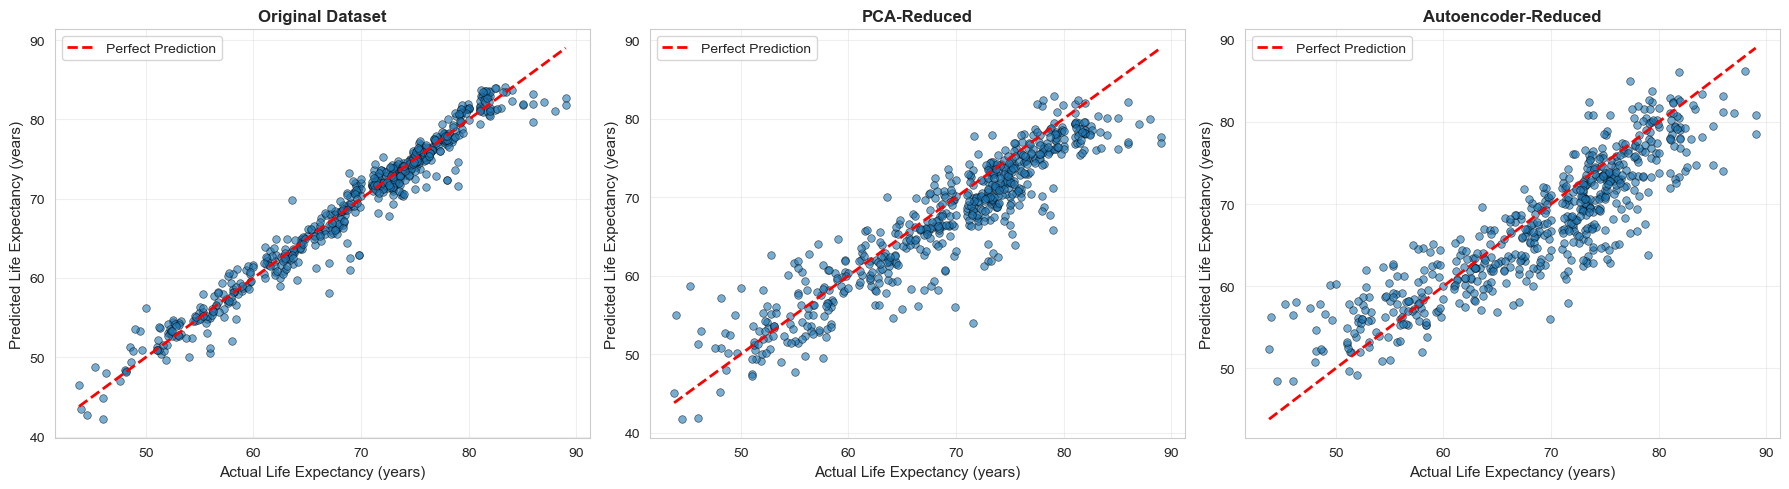

In [35]:
# Plot Predicted vs Actual for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    (pred_original, 'Original Dataset', axes[0]),
    (pred_pca, 'PCA-Reduced', axes[1]),
    (pred_ae, 'Autoencoder-Reduced', axes[2])
]

for predictions, title, ax in models_data:
    ax.scatter(y_test, predictions, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Life Expectancy (years)', fontsize=11)
    ax.set_ylabel('Predicted Life Expectancy (years)', fontsize=11)
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.2 Training and Validation Loss Curves

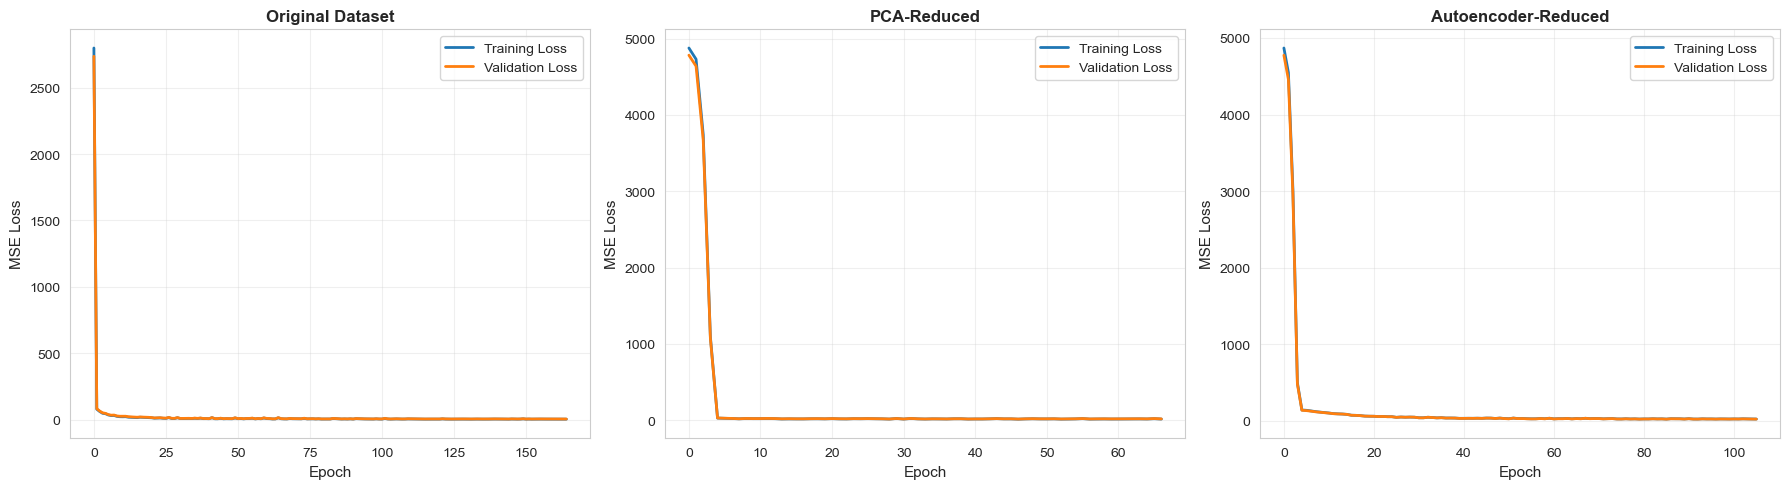

In [36]:
# Plot training and validation loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

histories = [
    (history_original, 'Original Dataset', axes[0]),
    (history_pca, 'PCA-Reduced', axes[1]),
    (history_ae, 'Autoencoder-Reduced', axes[2])
]

for history, title, ax in histories:
    ax.plot(history['train_loss'], label='Training Loss', linewidth=2)
    ax.plot(history['val_loss'], label='Validation Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('MSE Loss', fontsize=11)
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.3 Performance Metrics Comparison

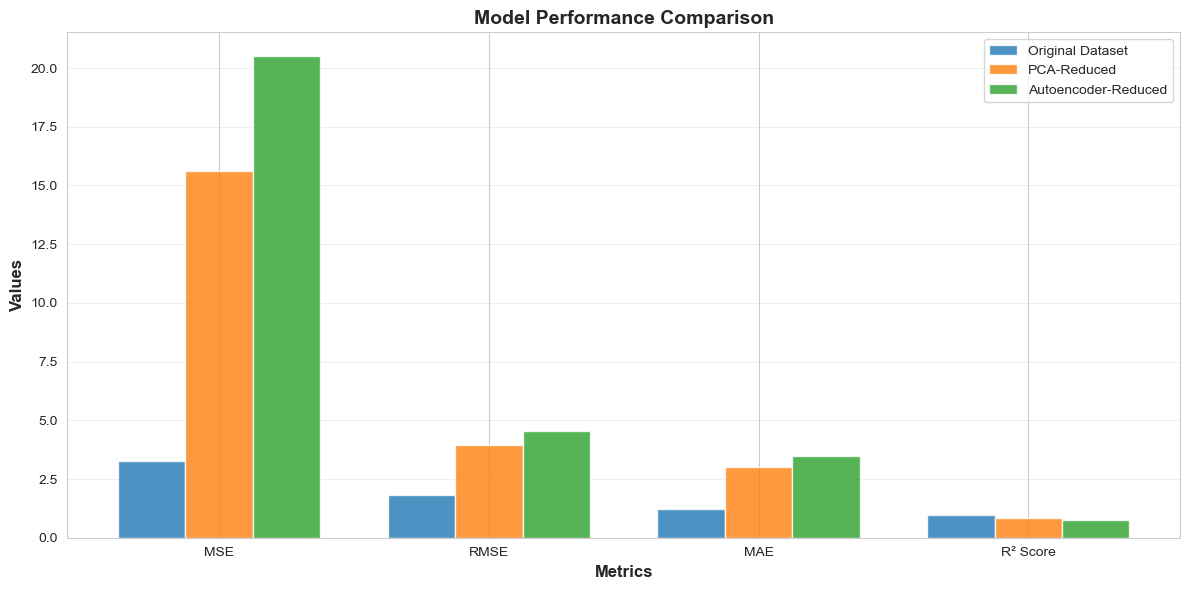

In [37]:
# Bar chart comparison of metrics
metrics_to_plot = ['MSE', 'RMSE', 'MAE', 'R² Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

values_original = [metrics_original[m] for m in metrics_to_plot]
values_pca = [metrics_pca[m] for m in metrics_to_plot]
values_ae = [metrics_ae[m] for m in metrics_to_plot]

bars1 = ax.bar(x - width, values_original, width, label='Original Dataset', alpha=0.8)
bars2 = ax.bar(x, values_pca, width, label='PCA-Reduced', alpha=0.8)
bars3 = ax.bar(x + width, values_ae, width, label='Autoencoder-Reduced', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Values', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 11.4 Total Processing Time (Including Dimensionality Reduction)

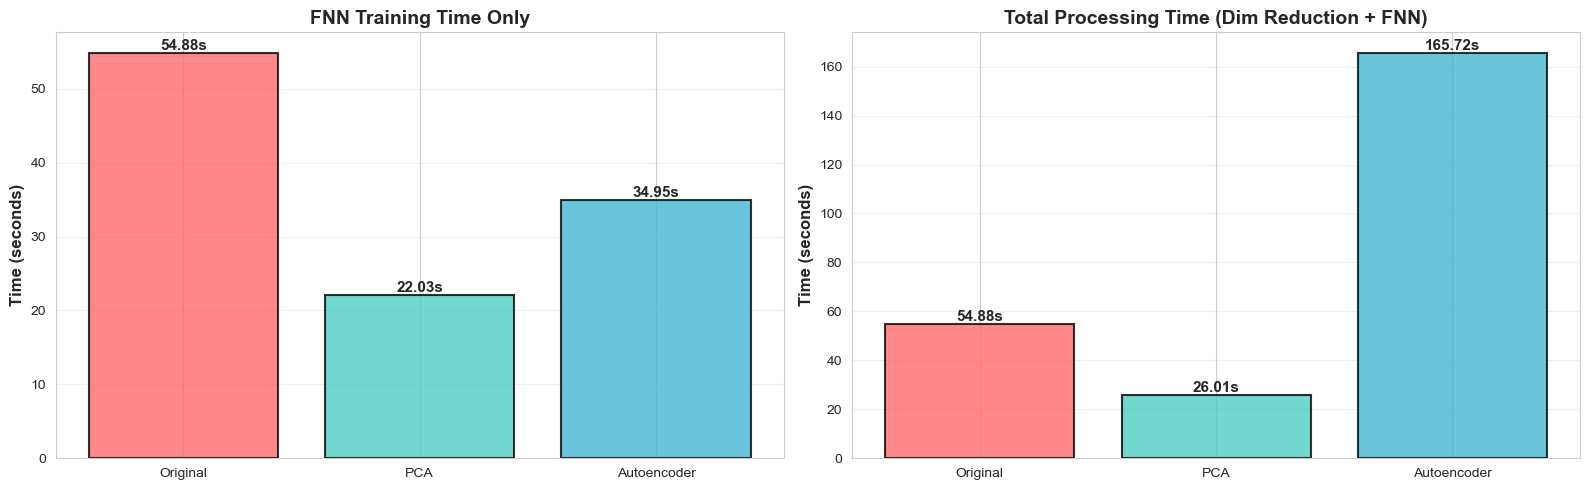

In [38]:
# Calculate total times
total_times = {
    'Original': time_original,
    'PCA': time_pca + pca_time,  # FNN training + PCA fitting
    'Autoencoder': time_ae + autoencoder_training_time  # FNN training + Autoencoder training
}

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: FNN Training Time Only
models = ['Original', 'PCA', 'Autoencoder']
fnn_times = [time_original, time_pca, time_ae]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars1 = ax[0].bar(models, fnn_times, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax[0].set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax[0].set_title('FNN Training Time Only', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

for bar, time_val in zip(bars1, fnn_times):
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height,
               f'{time_val:.2f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Total Processing Time
total_time_values = [total_times['Original'], total_times['PCA'], total_times['Autoencoder']]
bars2 = ax[1].bar(models, total_time_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax[1].set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax[1].set_title('Total Processing Time (Dim Reduction + FNN)', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', alpha=0.3)

for bar, time_val in zip(bars2, total_time_values):
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2., height,
               f'{time_val:.2f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 11.5 Feature Importance Analysis

Analyze which features have the greatest impact on model predictions using permutation importance. This technique measures how much the model's performance decreases when each feature's values are randomly shuffled.

Computing Feature Importance for Original Dataset Model...
(Using permutation importance on test set)

Top 15 Most Important Features (Original Dataset Model):

                         Feature  Importance
               Status_Developing   16.733401
                   Country_Italy    7.346547
                  Country_Norway    7.229971
             Country_Switzerland    6.811157
             Country_Netherlands    6.556166
                 Country_Austria    6.309795
                   Country_Japan    6.141345
                Country_Slovenia    5.335299
             Country_New Zealand    5.220353
              Country_Luxembourg    4.741681
 Income composition of resources    4.685451
                  Country_Cyprus    4.562250
                        HIV/AIDS    4.465785
Country_United States of America    4.188433
                 Country_Germany    4.019743


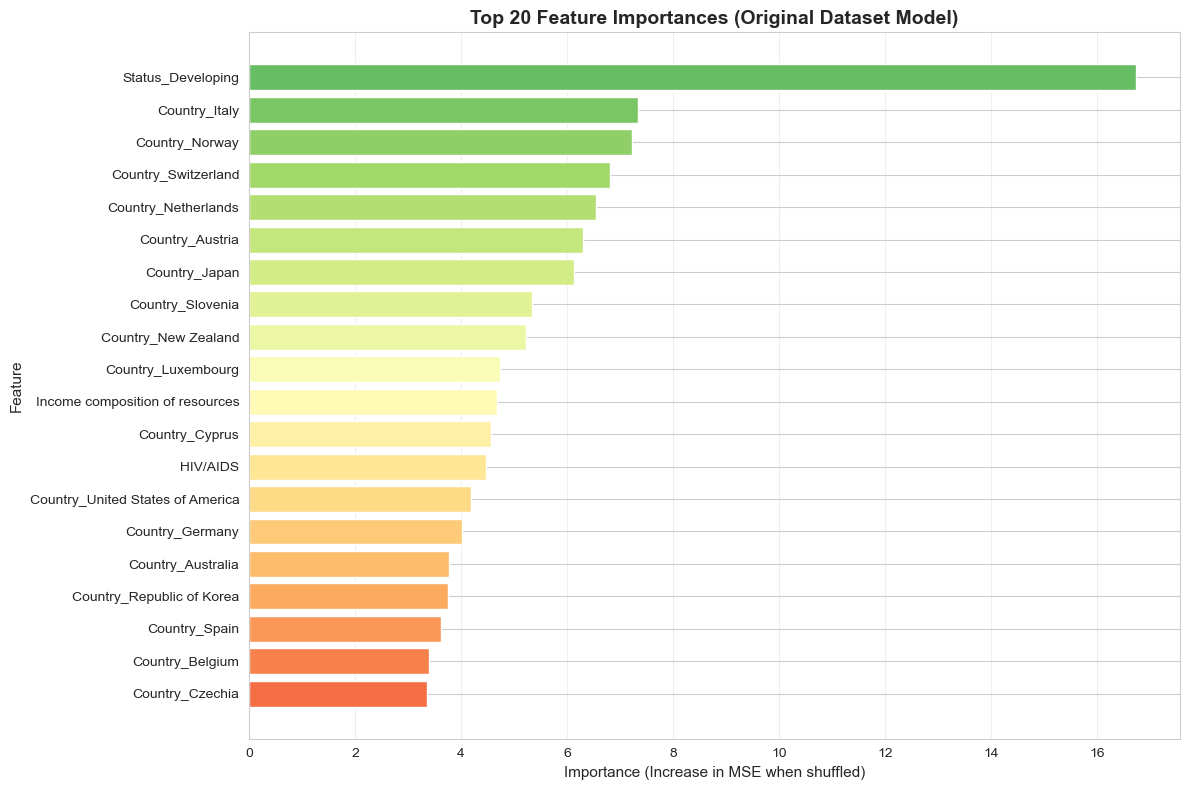

In [39]:
def compute_feature_importance(model, X, y, feature_names, model_name, n_repeats=10):
    """
    Compute permutation importance for a trained model.
    
    Returns:
        importance_df: DataFrame with feature importances sorted by importance
    """
    model.eval()
    
    # Create a wrapper function for sklearn's permutation_importance
    def model_predict(X_input):
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X_input).to(device)
            return model(X_tensor).cpu().numpy().flatten()
    
    # Calculate baseline predictions
    baseline_preds = model_predict(X)
    baseline_mse = mean_squared_error(y, baseline_preds)
    
    # Compute permutation importance manually for better control
    importances = []
    for i in range(X.shape[1]):
        feature_importances = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            np.random.shuffle(X_permuted[:, i])
            perm_preds = model_predict(X_permuted)
            perm_mse = mean_squared_error(y, perm_preds)
            # Importance = increase in error when feature is shuffled
            feature_importances.append(perm_mse - baseline_mse)
        importances.append(np.mean(feature_importances))
    
    # Create DataFrame with results
    importance_df = pd.DataFrame({
        'Feature': feature_names[:X.shape[1]],  # Handle dimensionality reduction
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    return importance_df

# Get feature names (for original dataset)
feature_names = X_train.columns.tolist()

# Compute importance for original dataset model (most interpretable)
print("Computing Feature Importance for Original Dataset Model...")
print("(Using permutation importance on test set)")
print()

importance_original = compute_feature_importance(
    fnn_original, X_test_scaled, y_test.values, feature_names, "Original", n_repeats=5
)

# Display top 15 most important features
print("Top 15 Most Important Features (Original Dataset Model):")
print()
print(importance_original.head(15).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_n = 20
top_features = importance_original.head(top_n)

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['Importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance (Increase in MSE when shuffled)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title(f'Top {top_n} Feature Importances (Original Dataset Model)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()